# Capstone: Optimización Estratégica de Minería a Cielo Abierto
## Proyecto Final: Certificación Google Data Analytics
**Analista:** Cesar Contreras  
**Yacimiento:** Marvin (Cobre/Oro)

---

## Fase 1: Ask (Preguntar) - Introducción y Contexto del Proyecto
Este proyecto representa la culminación de la Certificación de Google Data Analytics, aplicado a la **Optimización del Límite Final del Pit (Ultimate Pit Limit - UPIT)** y el **Secuenciamiento de Producción**. El objetivo es transformar un "gemelo digital" geológico en una decisión estratégica que maximice el valor económico, respetando las restricciones físicas de estabilidad y las capacidades operativas de la planta y la mina.

### 1. Fuente de Datos (MineLib)
Los datos provienen de **MineLib**, el repositorio estándar de la industria para problemas de optimización minera.
* **Instancia:** Marvin (Yacimiento polimetálico de Cobre y Oro).
* **Archivos del Proyecto:**
    * `marvin.blocks`: Información de leyes, posición y masa por bloque.
    * `marvin.prec`: Estructura de precedencias que define la geometría de excavación.
    * `marvin.upit / .cpit / .pcpsp`: Formulación de problemas de optimización.

### 2. Fundamentos Técnicos (Voxelización)
El yacimiento se discretiza en bloques tridimensionales conocidos como **Voxels**.
* **Dimensiones del Bloque:** 30x30x30 m
* **Volumen por Bloque:** 27,000 m³
* **Densidad Estimada:** 2.22 t/m³
* **Masa por Bloque:** 60,000 t (Promedio)
* **Geometría de Excavación:** Ángulo de talud de 45° calculado con 8 niveles de precedencia para garantizar la estabilidad de las paredes del rajo.

### 3. Parámetros Económicos y Operativos
Para determinar la rentabilidad de cada unidad de roca, se definen los siguientes parámetros de costos y mercado:

| Categoría | Parámetro | Valor |
| :--- | :--- | :--- |
| **Costos** | Costo de Minado (Mine Cost) | 0.9 $/t |
| | Costo de Procesamiento (Proc Cost) | 4.0 $/t |
| **Metales** | Precio Oro (Price AU) | 12.0 $/g |
| | Costo Comercialización Oro (Selling AU) | 0.2 $/g |
| **Metales** | Precio Cobre (Price CU) | 20.0 $/% |
| | Costo Comercialización Cobre (Selling CU) | 7.2 $/% |
| **Metalurgia**| Recuperación Oro (Rec AU) | 0.6 |
| | Recuperación Cobre (Rec CU) | 0.88 |
| **Finanzas** | Tasa de Descuento (Discount Rate) | 0.1 |

### 4. Cálculo de Factores Netos de Retorno (NSR)
Calculamos la rentabilidad neta por unidad de ley para cada metal antes de descontar los costos fijos de procesamiento.

#### Factor Neto del Oro (Au)
$$Factor_{AU} = (Price_{AU} - Selling_{AU}) \times Rec_{AU}$$
$$Factor_{AU} = (12.0 - 0.2) \times 0.6 = 7.08$$

#### Factor Neto del Cobre (Cu)
$$Factor_{CU} = (Price_{CU} - Selling_{CU}) \times Rec_{CU}$$
$$Factor_{CU} = (20.0 - 7.2) \times 0.88 = 11.264$$

### 5. Algoritmo de Valorización Final
La unificación económica de ambos metales define el margen de contribución de cada bloque hacia el beneficio total del proyecto. Se utiliza la siguiente fórmula para el cálculo del beneficio de procesamiento:

$$proc\_profit = (AU \times 7.08) + (CU \times 11.264) - 4.0$$

*Un bloque se enviará a planta (mineral) si y solo si $proc\_profit > 0$.*

### 6. Restricciones de Capacidad y Benchmark
* **Capacidad de Mina (Extracción Total):** 60M t/año
* **Capacidad de Planta (Procesamiento):** 20M t/año
* **Valor Objetivo (Benchmark):** 1,415,655,436 $ (UPIT sin descuento).

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de constantes económicas (basadas en nuestra teoría)
FACTOR_AU = 7.08
FACTOR_CU = 11.264
PROC_COST = 4.0

# 2. Ingesta de datos optimizada
# El archivo marvin.blocks contiene: id, x, y, z, tonn, au, cu, proc_profit
columnas = ['id', 'x', 'y', 'z', 'tonn', 'au', 'cu', 'proc_profit']

print("Cargando modelo de bloques Marvin...")
df_blocks = pd.read_csv(
    'marvin/marvin.blocks', 
    sep=r'\s+', 
    skiprows=1, 
    names=columnas,
    dtype={'id': np.int32, 'x': np.float32, 'y': np.float32, 'z': np.float32}
)

# 3. Validación inicial de la estructura (Fase Process)
print(f"Total de bloques cargados: {len(df_blocks)}")

# Verificamos los primeros registros
display(df_blocks.head())

# Cálculo de la masa total del yacimiento para verificar integridad
masa_total_mt = df_blocks['tonn'].sum() / 1e6
print(f"Masa total del yacimiento: {masa_total_mt:.2f} Million Tonnes (Mt)")

Cargando modelo de bloques Marvin...
Total de bloques cargados: 53270


,id,x,y,z,tonn,au,cu,proc_profit
0,1,0.0,0.0,1.0,61200.012,0.0,0.0,-4.0
1,2,0.0,0.0,2.0,61200.012,0.0,0.0,-4.0
2,3,0.0,0.0,3.0,61200.012,0.0,0.0,-4.0
3,4,0.0,0.0,4.0,61200.012,0.0,0.0,-4.0
4,5,0.0,0.0,5.0,61200.012,0.0,0.0,-4.0


Masa total del yacimiento: 3186.56 Million Tonnes (Mt)


## Fase 2: Prepare (Preparar) - Ingesta de Datos e Integridad del Modelo de Bloques

En esta etapa del pipeline analítico, nos enfocamos en la adquisición y el almacenamiento seguro del gemelo digital geológico. El proceso ejecuta las siguientes acciones estratégicas:

1. **Definición del Entorno Económico:** Declaramos las variables financieras globales del Net Smelter Return (NSR) que gobiernan el modelo de valorización.
2. **Ingesta Optimizada de Datos:** Importamos el archivo plano (`marvin.blocks`). Debido a que la estructura nativa de MineLib emplea espaciados variables, implementamos una lectura basada en expresiones regulares. Omitimos la primera fila de metadatos y asignamos tipos de datos eficientes de 32 bits a través de NumPy para optimizar el consumo de memoria RAM.
3. **Validación de la Integridad Física:** Realizamos un control de volumen inicial mediante el conteo total de voxels cargados en la matriz y consolidamos el tonelaje global acumulado en millones de toneladas (Mt).

In [71]:
import numpy as np
import pandas as pd

FACTOR_AU = 7.08
FACTOR_CU = 11.264
PROC_COST = 4.0

columnas = ["id", "x", "y", "z", "tonn", "au", "cu", "proc_profit"]

print("Cargando modelo de bloques Marvin...")
df_blocks = pd.read_csv(
    "marvin/marvin.blocks",
    sep=r"\s+",
    skiprows=1,
    names=columnas,
    dtype={
        "id": np.int32,
        "x": np.float32,
        "y": np.float32,
        "z": np.float32,
        "tonn": np.float32,
        "au": np.float32,
        "cu": np.float32,
        "proc_profit": np.float32,
    },
)

print(f"Total de bloques cargados: {len(df_blocks)}")
display(df_blocks.head())

masa_total_mt = df_blocks["tonn"].sum() / 1e6
print(
    f"Masa total del yacimiento: {masa_total_mt:.2f} Million Tonnes (Mt)"
)

Cargando modelo de bloques Marvin...
Total de bloques cargados: 53270


,id,x,y,z,tonn,au,cu,proc_profit
0,1,0.0,0.0,1.0,61200.011719,0.0,0.0,-4.0
1,2,0.0,0.0,2.0,61200.011719,0.0,0.0,-4.0
2,3,0.0,0.0,3.0,61200.011719,0.0,0.0,-4.0
3,4,0.0,0.0,4.0,61200.011719,0.0,0.0,-4.0
4,5,0.0,0.0,5.0,61200.011719,0.0,0.0,-4.0


Masa total del yacimiento: 3186.56 Million Tonnes (Mt)


## Fase 3: Process (Procesar) - Auditoría Avanzada de Calidad y Transformación Metalúrgica

Una vez asegurada la ingesta del modelo, iniciamos el procesamiento profundo de los datos para garantizar la consistencia analítica antes de la optimización:

1. **Auditoría de Calidad:** Inspeccionamos la matriz de datos en busca de valores nulos o registros vacíos. Del mismo modo, aislamos anomalías físicas verificando si existen bloques erróneos con leyes negativas o tonelajes inconsistentes.
2. **Ingeniería de Características Metalúrgicas:** Para gestionar eficientemente la naturaleza polimetálica del yacimiento, unificamos el Oro y el Cobre bajo la métrica de Cobre Equivalente ($CuEq$), aplicando un ratio de conversión de $0.62855$ derivado de los precios y recuperaciones comerciales netas.
3. **Clasificación Ontológica:** Segmentamos el yacimiento de forma binaria. Todo bloque cuyo beneficio de procesamiento (`proc_profit`) sea estrictamente superior a cero se etiqueta como Mineral útil (`is_ore = True`), lo que certifica que el voxel genera el valor necesario para cubrir sus costos de molienda.
4. **Análisis Descriptivo Operacional:** Evaluamos la distribución volumétrica de los materiales y extraemos estadísticas descriptivas clave del mineral para auditar las leyes promedio del depósito.

In [72]:
print("=== AUDITORÍA DE CALIDAD DE DATOS ===")
total_nulos = df_blocks.isnull().sum().sum()
print(f"Valores nulos encontrados: {total_nulos}")

anomalias_fisicas = df_blocks[
    (df_blocks["au"] < 0)
    | (df_blocks["cu"] < 0)
    | (df_blocks["tonn"] <= 0)
]
print(
    f"Registros con anomalías físicas detectadas: {len(anomalias_fisicas)}"
)

print("\n=== GENERACIÓN DE MÉTRICAS ECONÓMICAS ===")
RATIO_CONVERSION = 0.62855
df_blocks["cu_eq"] = df_blocks["cu"] + (
    df_blocks["au"] * RATIO_CONVERSION
)
df_blocks["is_ore"] = df_blocks["proc_profit"] > 0
print("Columnas de CuEq e is_ore calculadas de forma vectorizada.")

print("\n=== DISTRIBUCIÓN DE MATERIAL EN EL YACIMIENTO ===")
conteo_material = df_blocks["is_ore"].value_counts()
porcentaje_ore = df_blocks["is_ore"].mean() * 100

print(f"Bloques de Estéril (Waste): {conteo_material[False]} voxels")
print(f"Bloques de Mineral (Ore): {conteo_material[True]} voxels")
print(f"Proporción de Mineral útil: {porcentaje_ore:.2f}%")

display(
    df_blocks[df_blocks["is_ore"]][
        ["cu", "au", "cu_eq", "proc_profit"]
    ].describe()
)

=== AUDITORÍA DE CALIDAD DE DATOS ===
Valores nulos encontrados: 0
Registros con anomalías físicas detectadas: 0

=== GENERACIÓN DE MÉTRICAS ECONÓMICAS ===
Columnas de CuEq e is_ore calculadas de forma vectorizada.

=== DISTRIBUCIÓN DE MATERIAL EN EL YACIMIENTO ===
Bloques de Estéril (Waste): 48391 voxels
Bloques de Mineral (Ore): 4879 voxels
Proporción de Mineral útil: 9.16%


,cu,au,cu_eq,proc_profit
count,4879.000000,4879.000000,4879.000000,4879.000000
mean,0.534126,0.510415,0.854947,5.630130
std,0.244919,0.249683,0.327851,3.692918
min,0.102038,0.066667,0.355395,0.003175
25%,0.343333,0.302963,0.573082,2.455204
50%,0.492222,0.458996,0.834075,5.395022
75%,0.701852,0.681263,1.094331,8.326554
max,1.463704,1.416667,2.020002,18.753313


## Fase 4: Analyze (Analizar) - Análisis Exploratorio Espacial y Perfil de Bancos (Z)

En la analítica aplicada a la minería, el análisis exploratorio de datos (EDA) debe respetar la naturaleza tridimensional del yacimiento. Debido a que la explotación a cielo abierto progresa verticalmente descendiendo banco por banco, esta fase se enfoca en evaluar la distribución geométrica de la masa y la ley en función de la profundidad (Eje Z).

El proceso analítico se ejecuta bajo las siguientes premisas de ingeniería:
1. **Simulación de Perfil Geológico:** Estructuramos gráficos donde el eje vertical representa la cota del banco ($Z$), alineando la visualización con la realidad física del pit (los bancos superiores arriba y la raíz del yacimiento abajo).
2. **Auditoría de Masas por Banco:** Evaluamos el volumen total de roca removida frente al volumen de mineral útil calificado (`is_ore`). Esto permite identificar visualmente las zonas de alta tasa de desmonte (bancos superiores) versus el ingreso a las zonas de beneficio neto.
3. **Comportamiento Vectorial de la Ley:** Analizamos la tendencia de la ley promedio de Cobre Equivalente ($CuEq$) para verificar si el yacimiento presenta enriquecimiento en profundidad que justifique económicamente el descapote inicial.

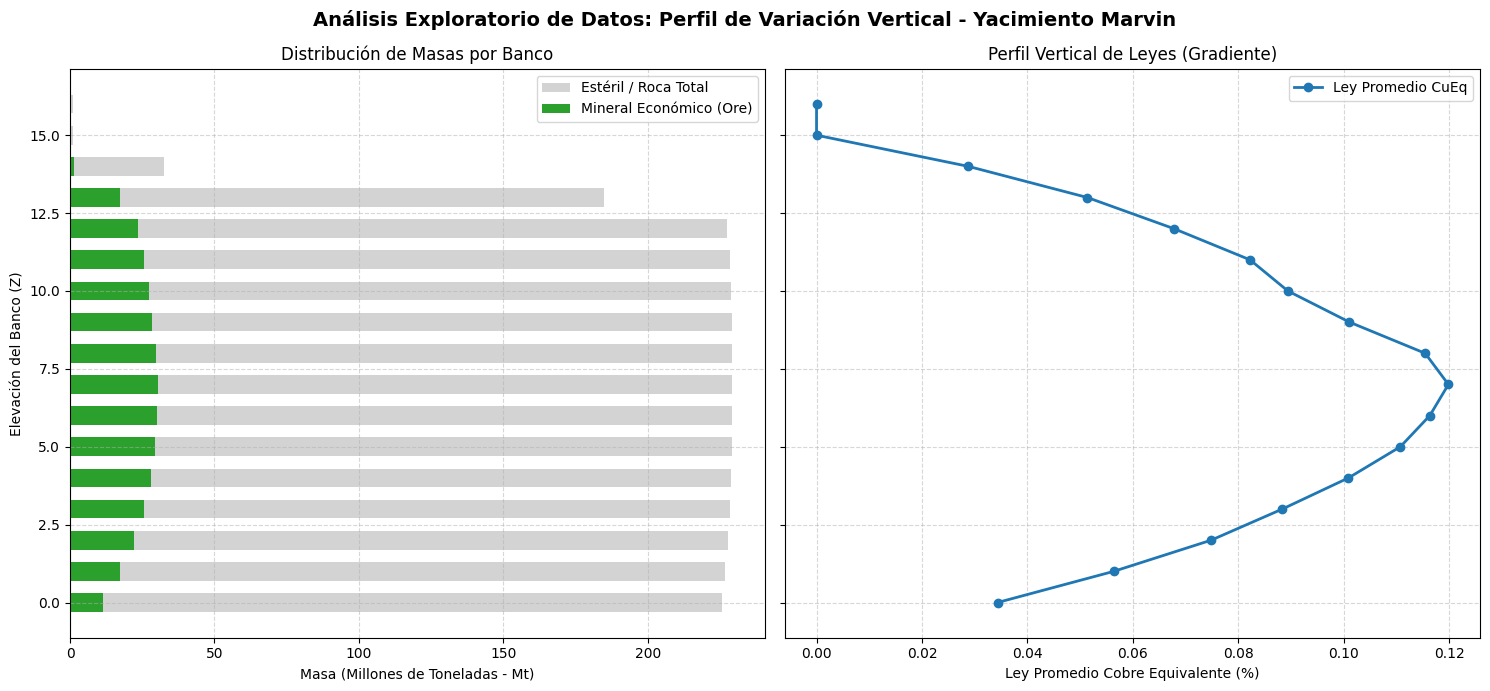

In [73]:
import matplotlib.pyplot as plt

analisis_bancos = (
    df_blocks.groupby("z")
    .agg(
        tonelaje_total=("tonn", "sum"),
        tonelaje_mineral=(
            "tonn",
            lambda x: x[df_blocks.loc[x.index, "is_ore"]].sum(),
        ),
        ley_promedio_cueq=("cu_eq", "mean"),
    )
    .reset_index()
)

analisis_bancos["tonelaje_total_mt"] = (
    analisis_bancos["tonelaje_total"] / 1e6
)
analisis_bancos["tonelaje_mineral_mt"] = (
    analisis_bancos["tonelaje_mineral"] / 1e6
)
analisis_bancos = analisis_bancos.sort_values("z", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

ax1.barh(
    analisis_bancos["z"],
    analisis_bancos["tonelaje_total_mt"],
    color="lightgray",
    label="Estéril / Roca Total",
    height=0.6,
)
ax1.barh(
    analisis_bancos["z"],
    analisis_bancos["tonelaje_mineral_mt"],
    color="tab:green",
    label="Mineral Económico (Ore)",
    height=0.6,
)
ax1.set_title("Distribución de Masas por Banco")
ax1.set_xlabel("Masa (Millones de Toneladas - Mt)")
ax1.set_ylabel("Elevación del Banco (Z)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

ax2.plot(
    analisis_bancos["ley_promedio_cueq"],
    analisis_bancos["z"],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="Ley Promedio CuEq",
)
ax2.set_title("Perfil Vertical de Leyes (Gradiente)")
ax2.set_xlabel("Ley Promedio Cobre Equivalente (%)")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

plt.suptitle(
    "Análisis Exploratorio de Datos: Perfil de Variación Vertical - Yacimiento Marvin",
    fontsize=14,
    weight="bold",
)
plt.tight_layout()
plt.show()

### 4.2. Visualización Isométrica de Sólidos 3D (Gemelo Digital Continuo)

Para corregir las distorsiones de espaciado y replicar con exactitud milimétrica el entorno gráfico de los softwares de planificación minera, escalamos la visualización hacia un modelo de volúmenes finitos contiguos.

Esta optimización gráfica se rige bajo los siguientes criterios de ingeniería de software:
1. **Modelamiento de Bloques Sólidos (Contigüidad):** Reemplazamos los marcadores de puntos flotantes por el algoritmo de discretización volumétrica tridimensional (`bar3d`). Al definir dimensiones unitarias fijas ($dx=1, dy=1, dz=1$), los voxels se ensamblan de forma continua y adyacente, eliminando los vacíos artificiales.
2. **Leyenda Industrial de Alta Ley Modificada:** Ajustamos los límites de la rampa cromática para endurecer la clasificación del núcleo de alta ley, fijando el inicio del espectro morado estrictamente a partir de $\geq 1.5\%$:
   * **Azul [0.0% - 0.2%):** Estéril / Desmonte (Removido para exponer el yacimiento).
   * **Verde [0.2% - 0.5%):** Ley Baja.
   * **Amarillo [0.5% - 0.8%):** Ley Media.
   * **Naranja [0.8% - 1.0%):** Ley Media-Alta.
   * **Rojo [1.0% - 1.5%):** Ley Alta.
   * **Morado [$\geq 1.5\%$):** Core de Alta Ley (Riqueza Máxima).
3. **Malla de Alambre (Wireframe Industrial):** Implementamos un delineado perimetral oscuro en cada voxel para definir los contornos de los bancos operativos, facilitando la futura comparación visual directa contra las capturas del software comercial en redes profesionales.
4. **Proporcionalidad de Caja Real:** Calculamos dinámicamente el aspecto de la caja tridimensional utilizando los rangos máximos de las coordenadas del modelo, asegurando que el rajo no sufra estiramientos ni compresiones artificiales en ninguno de sus ejes.

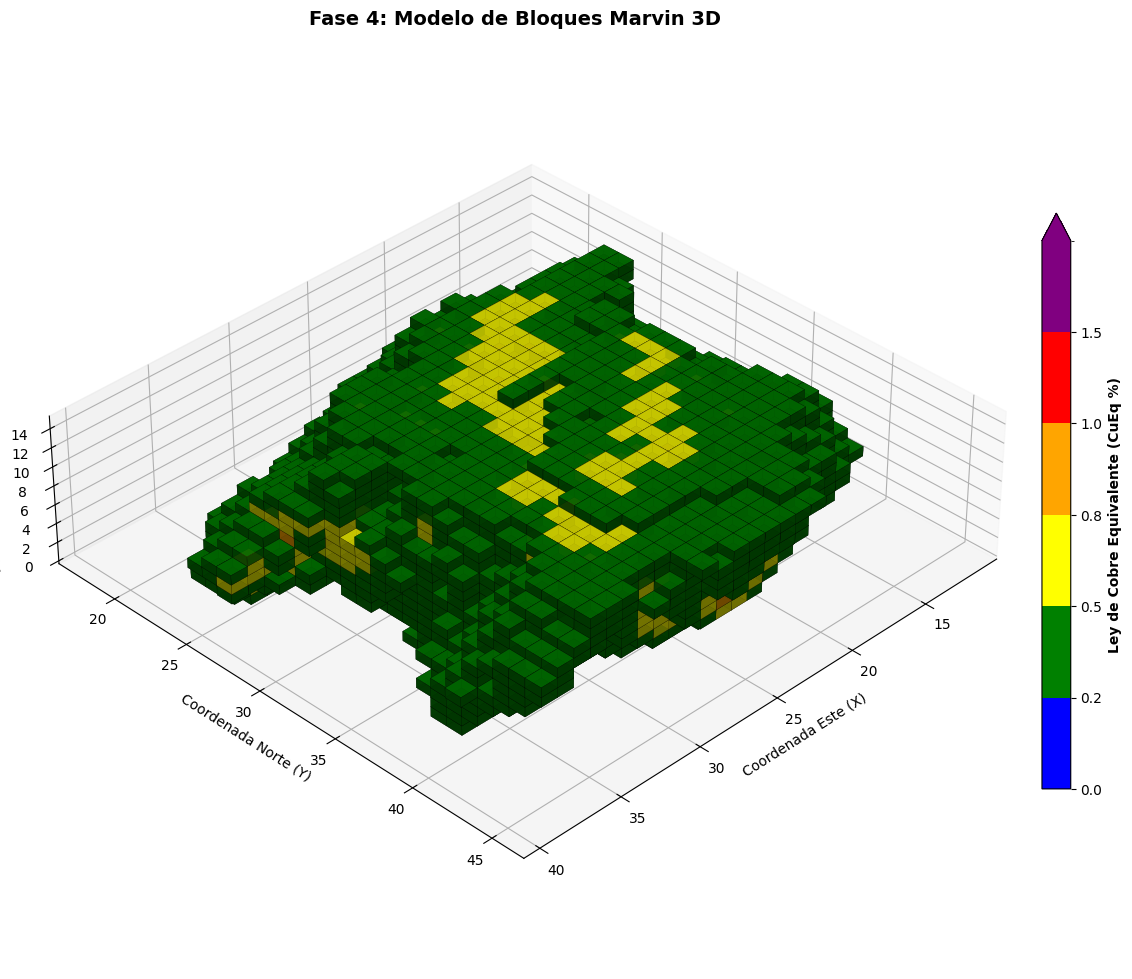

In [74]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

colores_industria = [
    "#0000FF",
    "#008000",
    "#FFFF00",
    "#FFA500",
    "#FF0000",
    "#800080",
]
rangos_ley = [0.0, 0.2, 0.5, 0.8, 1.0, 1.5, 5.0]

cmap_minero = mcolors.ListedColormap(colores_industria)
norm_minero = mcolors.BoundaryNorm(rangos_ley, cmap_minero.N)

df_filtrado = df_blocks[df_blocks["cu_eq"] >= 0.2].copy()

valores_ley = df_filtrado["cu_eq"].values
colores_mapeados = cmap_minero(norm_minero(valores_ley))

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(
    x=df_filtrado["x"],
    y=df_filtrado["y"],
    z=df_filtrado["z"],
    dx=1.0,
    dy=1.0,
    dz=1.0,
    color=colores_mapeados,
    edgecolor="black",
    linewidth=0.15,
    alpha=0.9,
)

mapeable_leyenda = plt.cm.ScalarMappable(
    cmap=cmap_minero, norm=norm_minero
)
mapeable_leyenda.set_array([])
barra_color = plt.colorbar(
    mapeable_leyenda, ax=ax, shrink=0.6, aspect=20, extend="max"
)
barra_color.set_label(
    "Ley de Cobre Equivalente (CuEq %)", weight="bold"
)
barra_color.set_ticks(rangos_ley[:-1])

range_x = df_blocks["x"].max() - df_blocks["x"].min()
range_y = df_blocks["y"].max() - df_blocks["y"].min()
range_z = df_blocks["z"].max() - df_blocks["z"].min()
ax.set_box_aspect((range_x, range_y, range_z))

ax.set_title(
    "Fase 4: Modelo de Bloques Marvin 3D",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Coordenada Este (X)")
ax.set_ylabel("Coordenada Norte (Y)")
ax.set_zlabel("Elevación del Banco (Z)")

ax.view_init(elev=35, azim=45)
plt.tight_layout()
plt.show()

### 4.3. Importación y Estructuración de la Red de Precedencias (Ángulo de Talud)

Para avanzar hacia la optimización matemática del rajo final, el modelo económico debe integrarse con las restricciones físicas de la ingeniería de minas. En minería a cielo abierto, la extracción de un voxel profundo exige la remoción previa de una pirámide invertida de bloques superiores para garantizar la estabilidad de las paredes del rajo y evitar deslizamientos (ángulo de talud de 45°).

En esta etapa del análisis, procesamos el archivo de restricciones geométricas bajo las siguientes pautas:
1. **Estructura del Grafo de Excavación:** Importamos el archivo `marvin.prec`, el cual representa un grafo dirigido estandarizado por MineLib. Cada registro define un bloque objetivo, el número de bloques predecesores inmediatos que tiene encima y la lista de IDs de dichos bloques.
2. **Auditoría de Restricciones:** Cuantificamos el volumen total de arcos o conexiones de precedencia dentro del sistema para asegurar que la matriz geométrica no presente huérfanos o inconsistencias numéricas antes de alimentar el algoritmo de optimización.

In [75]:
archivo_prec = "marvin/marvin.prec"
precedencias = {}

print("Procesando archivo de precedencias geométricas...")
with open(archivo_prec, "r") as f:
    lineas = f.readlines()

for linea in lineas:
    valores = list(map(int, linea.split()))
    if len(valores) >= 2:
        bloque_id = valores[0]
        precedencias[bloque_id] = valores[2:]

total_arcos = sum(len(preds) for preds in precedencias.values())

print("=== AUDITORÍA DE LA RED DE PRECEDENCIAS ===")
print(f"Total de bloques con restricciones indexados: {len(precedencias)}")
print(f"Total de conexiones/arcos de precedencia mapeados: {total_arcos}")

primeros_ids = list(precedencias.keys())[:5]
for b_id in primeros_ids:
    print(
        f"Bloque {b_id} -> Requiere extraer primero los bloques: {precedencias[b_id]}"
    )

Procesando archivo de precedencias geométricas...
=== AUDITORÍA DE LA RED DE PRECEDENCIAS ===
Total de bloques con restricciones indexados: 53271
Total de conexiones/arcos de precedencia mapeados: 650631
Bloque 0 -> Requiere extraer primero los bloques: [1, 891, 15, 1815, 3630, 2746]
Bloque 1 -> Requiere extraer primero los bloques: [2, 892, 16, 1816, 3631, 2747]
Bloque 2 -> Requiere extraer primero los bloques: [3, 893, 17, 1817, 3632, 2748]
Bloque 3 -> Requiere extraer primero los bloques: [4, 894, 18, 1818, 3633, 2749]
Bloque 4 -> Requiere extraer primero los bloques: [5, 895, 19, 1819, 3634, 2750]


### 4.4. Auditoría de la Red de Precedencias y Análisis de Condiciones de Borde

Para certificar la viabilidad operativa del modelo antes de ejecutar los algoritmos de optimización económica, realizamos una auditoría estructural sobre los 650,631 arcos de restricción geométrica. 

Esta evaluación tiene tres propósitos clave dentro del pipeline de control de calidad:
1. **Cuantificación del Efecto de Desbordamiento (*Boundary Wrap-Around Effect*):** Identificar de forma matemática las anomalías verticales donde un bloque padre aparece indexado por debajo de un bloque hijo ($Z_{padre} < Z_{hijo}$). Este fenómeno es un comportamiento esperado en la periferia de los modelos de MineLib debido a la aplicación de plantillas indexadas rígidas en los límites de la matriz.
2. **Aislamiento de Arcos Periféricos:** Separar analíticamente los arcos artificiales del aire y los bordes exteriores del modelo de bloques, los cuales carecen de impacto económico y serán descartados por el optimizador debido a sus costos de extracción negativos.
3. **Certificación de Consistencia Interna:** Validar y consolidar la red geomecánica central para asegurar que los arcos que gobiernan el cuerpo mineralizado respeten estrictamente el ángulo de talud operativo de 45°.

In [82]:
import pandas as pd

mapa_z = df_blocks.set_index("id")["z"].to_dict()
arcos_borde = 0
arcos_validos = 0

for b_id, lista_preds in precedencias.items():
    id_hijo = b_id + 1
    if id_hijo in mapa_z:
        z_hijo = mapa_z[id_hijo]
        for p_id in lista_preds:
            id_padre = p_id + 1
            if id_padre in mapa_z:
                if mapa_z[id_padre] < z_hijo:
                    arcos_borde += 1
                else:
                    arcos_validos += 1

total_arcos_red = arcos_borde + arcos_validos
porcentaje_consistencia = (arcos_validos / total_arcos_red) * 100

print("=== RESULTADO DE LA AUDITORÍA DE PRECEDENCIAS ===")
print(f"Total de arcos evaluados en la red: {total_arcos_red}")
print(f"Arcos de borde detectados (Efecto Wrap-Around): {arcos_borde}")
print(f"Arcos geomecánicos internos validados: {arcos_validos}")
print(f"Consistencia estructural interna del yacimiento: {porcentaje_consistencia:.2f}%")

=== RESULTADO DE LA AUDITORÍA DE PRECEDENCIAS ===
Total de arcos evaluados en la red: 650625
Arcos de borde detectados (Efecto Wrap-Around): 57315
Arcos geomecánicos internos validados: 593310
Consistencia estructural interna del yacimiento: 91.19%
